In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
# Importing of necessary libraries
import numpy as np
import pandas as pd

import tensorflow as tf

from keras.models import Sequential

import matplotlib.pyplot as plt
import shutil
import os
import cv2
import PIL as IMAGE

In [6]:
# Creating the path for the archive file and the extracted file for unzip
archive_file="/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2.zip"
image_path="/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images"


In [16]:
# Unpacking the zip file with shutil library
shutil.unpack_archive(archive_file, image_path)
print(f"Successfully unpacked '{archive_file}' to '{image_path}'.")

1. Plotting some images from the loaded data

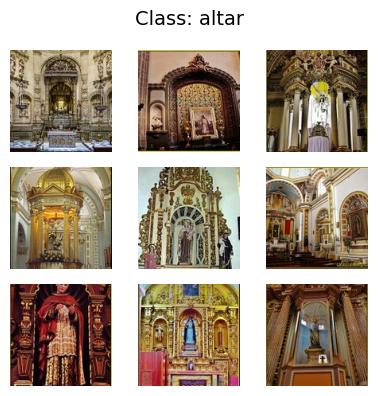

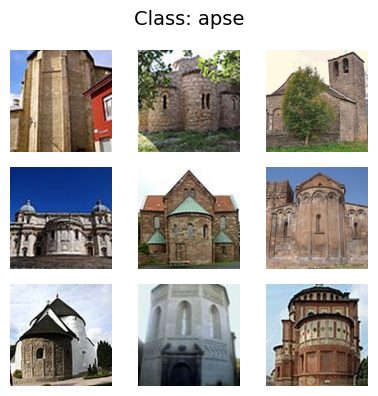

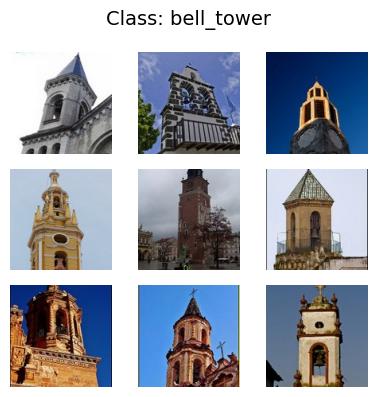

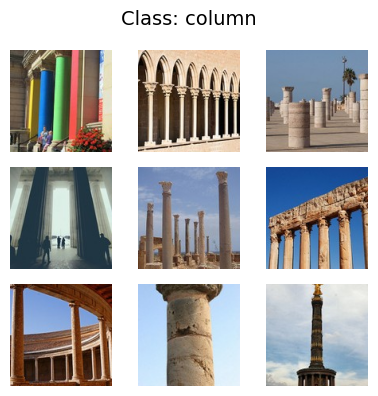

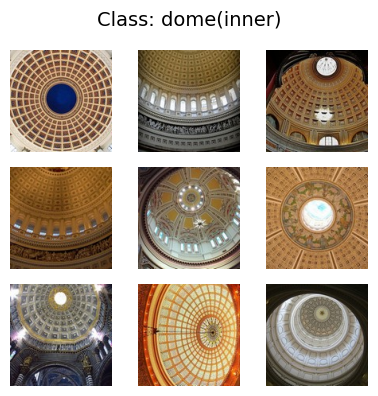

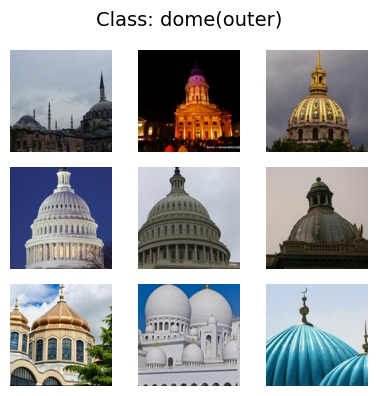

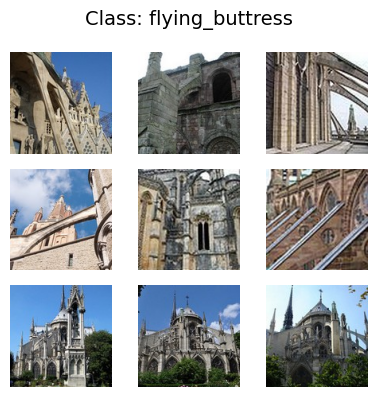

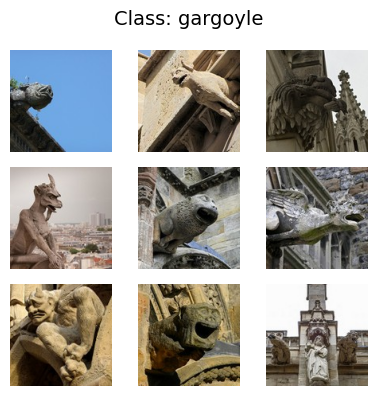

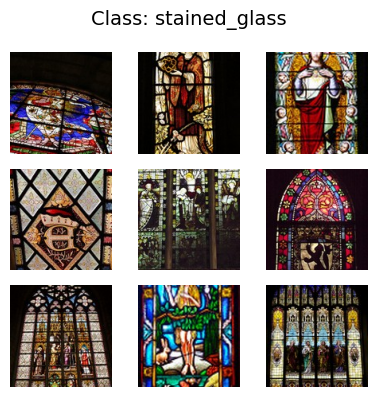

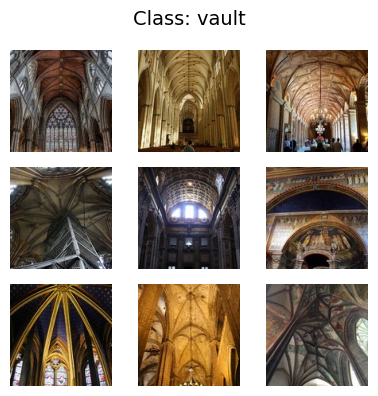

In [7]:
# Checking some images from each classes from the train dataset
import os
import random
import cv2
import matplotlib.pyplot as plt

# Path to dataset
train_path = "/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset"


# Number of samples per class
num_samples = 9

# Get class folders
classes = os.listdir(train_path)

for cls in classes:
    class_path = os.path.join(train_path, cls)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)

    # Randomly select images
    sample_images = random.sample(images, min(num_samples, len(images)))

    plt.figure(figsize=(4, 4))
    plt.suptitle(f"Class: {cls}", fontsize=14)

    for i, img_name in enumerate(sample_images):
        img_path = os.path.join(class_path, img_name)

        # Read image using OpenCV
        img = cv2.imread(img_path)

        if img is None:
            continue

        # Convert BGR → RGB (important for matplotlib)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(3, 3, i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

2. Building the CNN model

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [11]:
# Some of the images may be distorted so we must remove those corrupted images
from PIL import Image
import os
test_path = "/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478"   # 🔴 put your test folder path
test_dir=test_path

def remove_corrupted_images(directory):
    bad_files = []

    for root, _, files in os.walk(directory):
        for file in files:
            path = os.path.join(root, file)

            try:
                img = Image.open(path)
                img.verify()   # verify integrity
            except Exception as e:
                print(f"Removing corrupted file: {path}")
                bad_files.append(path)
                os.remove(path)

    print(f"\nTotal removed: {len(bad_files)} images")

remove_corrupted_images(test_dir)


Total removed: 0 images


In [10]:
# Image file gernation without augmentation
# First defining the directory of train and test data set. Train train data has been generated through the Image genrator just by scalling the data without augmentation
# from the train data 20% of the data has been taken for the validation
# each class category has been encoded through the alphabetical encoding method

from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (128, 128)
batch_size = 32

train_dir = train_path
test_path = "/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478"   # 🔴 put your test folder path
test_dir=test_path
# Train + Validation generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

# Test generator (NO split, NO augmentation)
test_datagen = ImageDataGenerator(rescale=1./255)

# Train
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Validation
val_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

# Test
test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

num_classes = train_gen.num_classes

print("Classes:", train_gen.class_indices)

Found 8193 images belonging to 10 classes.
Found 2042 images belonging to 10 classes.
Found 1475 images belonging to 10 classes.
Classes: {'altar': 0, 'apse': 1, 'bell_tower': 2, 'column': 3, 'dome(inner)': 4, 'dome(outer)': 5, 'flying_buttress': 6, 'gargoyle': 7, 'stained_glass': 8, 'vault': 9}


In [43]:
# Removal of the corrupted file from the data
remove_corrupted_images(train_dir)
remove_corrupted_images(test_dir)

Removing corrupted file: /content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/.DS_Store

Total removed: 1 images

Total removed: 0 images


In [12]:
# print(train_gen.class_indices)
print("-----------")
print(test_gen.class_indices)

-----------
{'altar': 0, 'apse': 1, 'bell_tower': 2, 'column': 3, 'dome(inner)': 4, 'dome(outer)': 5, 'flying_buttress': 6, 'gargoyle': 7, 'stained_glass': 8, 'vault': 9}


In [21]:
# Check some images and their class (encoded)
for i in range(5):
    print(test_gen.filepaths[i], test_gen.classes[i])

/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478/altar/00947185-77b4-4ecf-85ed-bf139c7d5a1d.jpg 0
/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478/altar/010c7d48-02ad-4663-ba27-9670d8ccff60.jpg 0
/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478/altar/018420ac-b243-4d97-977b-f10d32121288.jpg 0
/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478/altar/0624cbfa-c730-4876-9958-87bbdb4290fa.jpg 0
/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478/altar/064ffa6f-8be6-404c-a661

In [22]:
print(test_gen.filepaths[200])   # full image paths
print(test_gen.classes[200])     # numeric labels

/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Dataset_test/Dataset_test_original_1478/bell_tower/0c471e30-17bc-48c2-83cd-dd3c6641e95b.jpg
2


In [23]:
print(train_gen.filepaths[:10])
print(train_gen.classes[:10])

['/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/altar/15345012914_2eed6cde5b_m.jpg', '/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/altar/15391950498_77c0516dc0_m.jpg', '/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/altar/15449134436_e81a4ac310_n.jpg', '/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/altar/15497882346_90c0564386.jpg', '/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/altar/15520667782_25e11c96ee.jpg', '/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/altar/15605539

In [24]:
train_gen.filepaths[900]

'/content/drive/MyDrive/Abhijit/Capstone/Capstone_Heritage/Images/dataset_hist_structures 2/dataset_hist_structures/Stuctures_Dataset/apse/8644962627_323730911f.jpg'

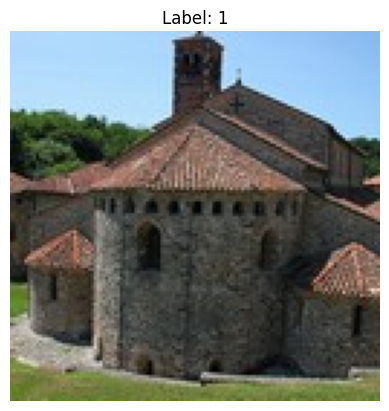

In [25]:
# visualization one image and its label class from the train data
image_filepath = train_gen.filepaths[900]
label = train_gen.classes[900]

# Load the image using OpenCV
img = cv2.imread(image_filepath)

# Convert BGR to RGB (matplotlib expects RGB)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis('off') # Hide axes for cleaner display
plt.show()

3. Transfer Learning : CNN Model Building  with the pretrained Resnet50 as basemodel

In [13]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import ResNet50

In [14]:
# base model architecture
base_model = ResNet50(
    weights='imagenet',   # using pretrained weights
    include_top=False,    # removal of classification head
    input_shape=(128, 128, 3)
)

base_model.trainable = False   # freezing backbone

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [28]:
print("Classes:", train_gen.class_indices) # Check class labels

Classes: {'altar': 0, 'apse': 1, 'bell_tower': 2, 'column': 3, 'dome(inner)': 4, 'dome(outer)': 5, 'flying_buttress': 6, 'gargoyle': 7, 'stained_glass': 8, 'vault': 9}


In [ ]:
num_classes=len(train_gen.class_indices) # Number of classes in the train dataset
num_classes

4. Modify the top of the model architecture

*   Adding an appropriate number of dense layers with an activation function
*   Using dropout for regularization



In [30]:
# Using the basemodel output as the input for the Dense layer of the CNN model

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [31]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

5. Compilation of the model

In [32]:
# model compilation
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [33]:
# fitting the data with the model
history = model.fit(
    train_gen,
    validation_data=val_gen,
    batch_size=64,
    epochs=10

)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 2512s 10s/step - accuracy: 0.2642 - loss: 2.1002 - val_accuracy: 0.3741 - val_loss: 1.9056
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 631s 2s/step - accuracy: 0.3422 - loss: 1.8909 - val_accuracy: 0.3976 - val_loss: 1.7937
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 679s 2s/step - accuracy: 0.3785 - loss: 1.8038 - val_accuracy: 0.4060 - val_loss: 1.7264
Epoch 4/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 625s 2s/step - accuracy: 0.4035 - loss: 1.7250 - val_accuracy: 0.4182 - val_loss: 1.6552
Epoch 5/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 625s 2s/step - accuracy: 0.4227 - loss: 1.6673 - val_accuracy: 0.4412 - val_loss: 1.5992
Epoch 6/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 641s 2s/step - accuracy: 0.4393 - loss: 1.6217 - val_accuracy: 0.4814 - val_loss: 1.5429
Epoch 7/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 644s 3s/step - accuracy: 0.4669 - loss: 1.5771 - val_accuracy: 0.4907 - val_loss: 1.5022
Epoch 8/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 627s 2s/step - accuracy: 0.4625 - loss: 1.5777 - val_ac

Model accuracy improves with the epochs and validation loss decreases with the epochs. Therefore, more epochs can fix into the better performance.

In [42]:
# checking the loss and accuracy with the test data
loss, accuracy = model.evaluate(test_gen)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.4454 - loss: 1.6280
Test Loss: 1.6280131340026855
Test Accuracy: 0.4454237222671509


In [44]:
# Prediction of the class from the test data
y_pred = model.predict(test_gen)


47/47 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step


In [45]:
# prediction of the class from the test data set the from the predicted probability of y_pred values
import numpy as np
y_pred_classes = np.argmax(y_pred, axis=1)
y_pred_classes

array([3, 0, 0, ..., 0, 9, 7])

In [46]:
# True classes from teh test data
y_true = test_gen.classes
y_true

array([0, 0, 0, ..., 9, 9, 9], dtype=int32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
Predicted: dome(inner)
Actual: dome(inner)


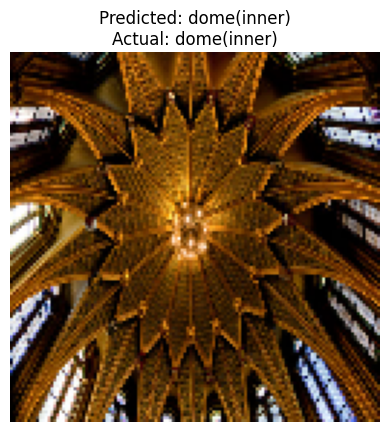

In [53]:
# Import an random images from the test director and check the predicion with the true values
import random

file_paths = test_gen.filepaths # Map the filepath to its original class index using test_gen's structure
img_path = random.choice(file_paths)

# load image using cv2.imread
img = cv2.imread(img_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Unable to load image at {img_path}")
else:
    # Convert BGR to RGB ( As OpenCV loads images in BGR by default)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image to the target size (128, 128) used during training
    target_size = (128, 128) # As defined in img_size earlier
    img_resized = cv2.resize(img, target_size)

    # Convert image to array and normalize
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # prediction of classes
    prediction = model.predict(img_array)
    pred_class = np.argmax(prediction, axis=1)[0]

    # labels for classes
    class_labels = dict((v, k) for k, v in test_gen.class_indices.items())

    predicted_label = class_labels[pred_class]


    # Find the true label corresponding to the image path
    # For simplicity, assuming file_paths.index(img_path) gives the correct index into test_gen.classes
    true_label_index = test_gen.filepaths.index(img_path)
    true_label = class_labels[test_gen.classes[true_label_index]]

    print("Predicted:", predicted_label)
    print("Actual:", true_label)

    # Display the image with its predicted and actual labels
    plt.imshow(img_resized)
    plt.title(f"Predicted: {predicted_label}\nActual: {true_label}")
    plt.axis('off')

    plt.show()

For some images it correctly predict the class but for other images it can not prdict the right class. It is possibly due to the poor (~50%) training and validation accracy. The testing acuracy is also poor, about 44%. We need to check with the augmented data.

# Model performance with Augmented image data

In [26]:
# Augmentation of the images by changing the zoom and brightness modulation
advanced_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    zoom_range=0.05,
    brightness_range=[0.9, 1.1]
)

In [27]:
# Dataset assigment with passing the label of augmentation
train_gen_aug = advanced_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen_aug = advanced_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)
# We don't need any augmentation for the tes data set

Found 8193 images belonging to 10 classes.
Found 2042 images belonging to 10 classes.


In [ ]:
# Function to check the number of images in each class subfolder for train and test data set
import os

def count_images(folder):
    class_counts = {}

    for class_name in os.listdir(folder):
        class_path = os.path.join(folder, class_name)

        if os.path.isdir(class_path):
            num_images = len(os.listdir(class_path))
            class_counts[class_name] = num_images

    return class_counts

train_counts = count_images(train_dir)
test_counts = count_images(test_dir)

print("Train:", train_counts)
print("Test:", test_counts)

In [31]:
# Count of the number of images in each train class subfolder
class_labels = {v: k for k, v in train_gen.class_indices.items()}

train_distribution = {class_labels[k]: v for k, v in train_counts.items()}

print("Train distribution (label-wise):")
for k, v in train_distribution.items():
    print(f"{k}: {v}")

Train distribution (label-wise):
altar: 664
apse: 412
bell_tower: 848
column: 1536
dome(inner): 493
dome(outer): 942
flying_buttress: 326
gargoyle: 1257
stained_glass: 827
vault: 888


In [34]:
# Count of the number of images in each train class subfolder
class_labels = {v: k for k, v in test_gen.class_indices.items()}

test_distribution = {class_labels[k]: v for k, v in test_counts.items()}

print("Train distribution (label-wise):")
for k, v in test_distribution.items():
    print(f"{k}: {v}")

Train distribution (label-wise):
altar: 140
apse: 57
bell_tower: 170
column: 210
dome(inner): 86
dome(outer): 168
flying_buttress: 78
gargoyle: 240
stained_glass: 162
vault: 164


Using the same model for Training

In [17]:
# same base model for transfer learning
base_model = ResNet50(
    weights='imagenet',   # pretrained weights used
    include_top=False,    # removal of classification head
    input_shape=(128, 128, 3)
)

base_model.trainable = False   # freeze backbone

In [18]:
# same base model output for pass into the Dense layer
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model_res50 = Model(inputs=base_model.input, outputs=outputs) # Model renamed for better handling

In [19]:
model_res50.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 134, 134,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 64, 64,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 64, 64,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 64, 64,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 66, 66,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 32, 32,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 32, 32,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 32, 32,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 32, 32,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 32, 32,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 32, 32,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 32, 32,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 32, 32,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 32, 32,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 32, 32,    │      1,024 │ conv2_block1_3_c

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [35]:
# Model compilation
model_res50.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
# Defining of calbacks to stop the training once validation accuracy reaches a certain
number of your choice
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, verbose=1),
    ModelCheckpoint("best_resnet50.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [37]:
# Model fit with propagation of steps
history_res50 = model_res50.fit(
    train_gen_aug,
    validation_data=val_gen_aug,
    batch_size=64,
    callbacks=callbacks,
    epochs=10

)

Epoch 1/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.2115 - loss: 2.2037
Epoch 1: val_accuracy improved from None to 0.35064, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 2615s 10s/step - accuracy: 0.2574 - loss: 2.1082 - val_accuracy: 0.3506 - val_loss: 1.9411 - learning_rate: 0.0010
Epoch 2/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3222 - loss: 1.9440
Epoch 2: val_accuracy improved from 0.35064 to 0.38688, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
257/257 ━━━━━━━━━━━━━━━━━━━━ 786s 3s/step - accuracy: 0.3333 - loss: 1.9215 - val_accuracy: 0.3869 - val_loss: 1.8173 - learning_rate: 0.0010
Epoch 3/10
257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3480 - loss: 1.8615
Epoch 3: val_accuracy improved from 0.38688 to 0.40793, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
257/257 ━━━━━━━━━━━━━

In [38]:
# Check the loss and acuracy with the test data
loss, accuracy = model_res50.evaluate(test_gen)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

47/47 ━━━━━━━━━━━━━━━━━━━━ 104s 2s/step - accuracy: 0.4542 - loss: 1.5939
Test Loss: 1.5939288139343262
Test Accuracy: 0.45423728227615356


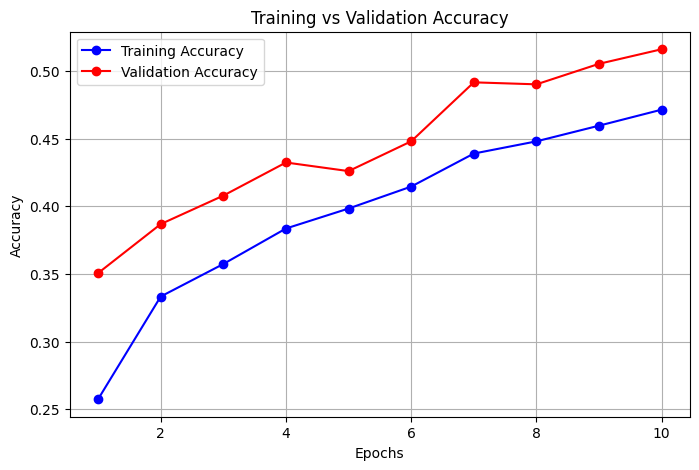

In [51]:

# Check the model performance with epochs

import matplotlib.pyplot as plt

# Extract values
train_acc = history_res50.history['accuracy']
val_acc = history_res50.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_acc, 'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

Training and validation accuracy do not improve so much with 10 epochs but saturation point not achieved with 10 epochs. Possibly due to the bas model training performance.

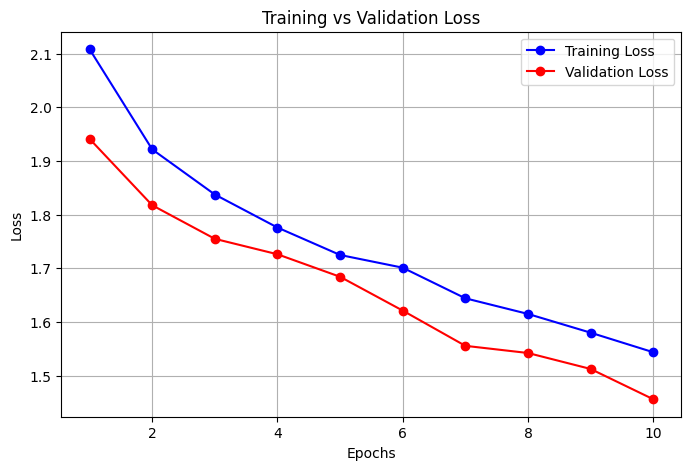

In [52]:
train_loss = history_res50.history['loss']
val_loss = history_res50.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(epochs, train_loss, 'bo-', label='Training Loss')
plt.plot(epochs, val_loss, 'ro-', label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Model performance imporve with the epochs and saturation point not achieved with 10 epochs. Possibly more epochs cn decrease the training and validation loss.

In [39]:
remove_corrupted_images(train_dir) #cross check
remove_corrupted_images(test_dir)# cross check for performance


Total removed: 0 images

Total removed: 0 images


In [41]:
# Prediction of class probabilities of the test data
y_pred_res50 = model_res50.predict(test_gen)


47/47 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step


In [42]:
## Prediction of class of the test data from the class probabilities
import numpy as np
y_pred_classes_res50 = np.argmax(y_pred_res50, axis=1)
y_pred_classes_res50

array([3, 8, 0, ..., 9, 9, 8])

In [43]:
# check of the true classes
y_true = test_gen.classes
y_true

array([0, 0, 0, ..., 9, 9, 9], dtype=int32)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Predicted: stained_glass
Actual: stained_glass


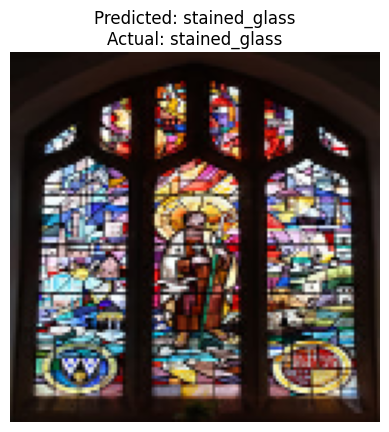

In [47]:
# visualtion of the model performance by calling a random image from the test data set and comapring with the true class labels

file_paths = test_gen.filepaths
img_path = random.choice(file_paths)

# load image using cv2.imread and preprocess
img = cv2.imread(img_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Unable to load image at {img_path}")
else:
    # Convert BGR to RGB (OpenCV loads images in BGR by default)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image to the target size (128, 128) used during training
    target_size = (128, 128) # As defined in img_size earlier
    img_resized = cv2.resize(img, target_size)

    # Convert image to array and normalize
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    prediction = model_res50.predict(img_array)
    pred_class_res50 = np.argmax(prediction, axis=1)[0]

    # labels
    class_labels = dict((v, k) for k, v in test_gen.class_indices.items())

    predicted_label_res50 = class_labels[pred_class_res50]

    # Find the true label corresponding to the image path
    # For simplicity, assuming file_paths.index(img_path) gives the correct index into test_gen.classes
    true_label_index = test_gen.filepaths.index(img_path) #  map the filepath to its original class index using test_gen's structure
    true_label = class_labels[test_gen.classes[true_label_index]]

    print("Predicted:", predicted_label_res50)
    print("Actual:", true_label)

    # Display the image with its predicted and actual labels
    plt.imshow(img_resized)
    plt.title(f"Predicted: {predicted_label_res50}\nActual: {true_label}")
    plt.axis('off')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predicted: gargoyle
Actual: vault


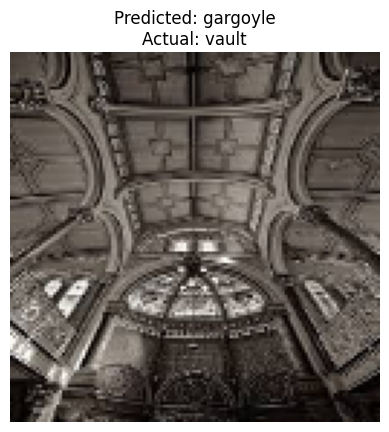

In [48]:
# # Check for the 2nd time
# visualtion of the model performance by calling a random image from the test data set and comapring with the true class labels

file_paths = test_gen.filepaths
img_path = random.choice(file_paths)

# load image using cv2.imread and preprocess
img = cv2.imread(img_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Unable to load image at {img_path}")
else:
    # Convert BGR to RGB (OpenCV loads images in BGR by default)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize image to the target size (128, 128) used during training
    target_size = (128, 128) # As defined in img_size earlier
    img_resized = cv2.resize(img, target_size)

    # Convert image to array and normalize
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    prediction = model_res50.predict(img_array)
    pred_class_res50 = np.argmax(prediction, axis=1)[0]

    # labels
    class_labels = dict((v, k) for k, v in test_gen.class_indices.items())

    predicted_label_res50 = class_labels[pred_class_res50]

    # Find the true label corresponding to the image path
    # For simplicity, assuming file_paths.index(img_path) gives the correct index into test_gen.classes
    true_label_index = test_gen.filepaths.index(img_path) #  map the filepath to its original class index using test_gen's structure
    true_label = class_labels[test_gen.classes[true_label_index]]

    print("Predicted:", predicted_label_res50)
    print("Actual:", true_label)

    # Display the image with its predicted and actual labels
    plt.imshow(img_resized)
    plt.title(f"Predicted: {predicted_label_res50}\nActual: {true_label}")
    plt.axis('off')

    plt.show()

Sometimes model predicts the corrects class labeling and sometimes not from randomly selected images from the test directoty. It is due to the low model accuracy towards the validation and testing accuracy.